<a href="https://colab.research.google.com/github/harshitt018/Advance-Data-Science/blob/main/Chapter%203%3A%20Forecasting%20with%20Exponential%20Smoothing%20Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chapter 3: Forecasting with Exponential Smoothing Methods**

Forecasting is the process of predicting future values based on historical observations. In time series analysis, Exponential Smoothing methods are widely used because they assign greater importance to recent observations while still considering past data.

This chapter focuses on applying different Exponential Smoothing techniques to the Mumbai Rainfall dataset. The objective is to compare multiple forecasting models and determine which method provides the most accurate rainfall predictions.

The following forecasting methods are studied:

- Simple Exponential Smoothing (SES)
- Holt’s Linear Trend Method
- Holt-Winters Additive Method
- Holt-Winters Multiplicative Method

The performance of each model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). Finally, the best-performing model is selected and used to forecast Mumbai rainfall for the years 2022–2026.

# **Step 1: Importing Required Libraries**

In this step, all the required libraries for data processing, visualization, forecasting, and model evaluation were imported.

### Libraries Used

- **Pandas** – Used for loading and handling the rainfall dataset.
- **NumPy** – Used for numerical computations.
- **Matplotlib** – Used for plotting graphs and visualizations.
- **SimpleExpSmoothing** – Used for Simple Exponential Smoothing (SES).
- **Holt** – Used for Holt’s Linear Trend Method.
- **ExponentialSmoothing** – Used for Holt-Winters forecasting models.
- **MAE & RMSE** – Used to evaluate forecasting accuracy.
- **Warnings** – Suppressed to keep the output clean.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt,
    ExponentialSmoothing
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings('ignore')

# **Step 2: Loading the Mumbai Rainfall [Dataset](https://www.kaggle.com/datasets/macaronimutton/mumbai-rainfall-data)**

In this step, the Mumbai Monthly Rainfall dataset was loaded into a Pandas DataFrame using the `read_csv()` function. The `head()` function was then used to display the first five records of the dataset.

### Dataset Overview

The dataset contains monthly rainfall measurements recorded in Mumbai from **1901 onwards**. Each row represents a particular year, while each column represents the rainfall recorded during a specific month.

### Understanding the Output

- **Year** column represents the observation year.
- **Jan to Dec** columns contain monthly rainfall values in millimeters (mm).
- **Total** column contains the total annual rainfall for that year.
- Each row corresponds to one complete year's rainfall record.

For example:

- In **1901**, the highest rainfall was recorded during **July (888.37 mm)** and **June (640.71 mm)**.
- In **1902**, significant rainfall was observed during **August (566.60 mm)** and **September (688.91 mm)**.
- Very low rainfall values can be observed during winter months such as January, February, and December.

The output confirms that the dataset has been loaded successfully and contains monthly rainfall information that can be used for time series forecasting.

In [5]:
df = pd.read_csv("/content/mumbai-monthly-rains.csv")

df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250


# **Step 3: Understanding the Dataset Structure**

In this step, the shape and structure of the dataset were examined using the `shape` and `info()` functions.

### Dataset Information

- The dataset contains **121 rows** and **14 columns**.
- Each row represents rainfall data for one year.
- The dataset covers the period from **1901 to 2021**.
- There are **12 monthly rainfall columns** (January to December).
- An additional **Total** column stores the annual rainfall amount.
- The **Year** column is stored as an integer (`int64`).
- All rainfall values are stored as decimal numbers (`float64`).

### Understanding the Output

- **Dataset Shape: (121, 14)**
  - 121 yearly observations.
  - 14 total columns.

- **Non-Null Count**
  - Every column contains **121 non-null values**.
  - This indicates that there are **no missing values** in the dataset.



In [6]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (121, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    121 non-null    int64  
 1   Jan     121 non-null    float64
 2   Feb     121 non-null    float64
 3   Mar     121 non-null    float64
 4   April   121 non-null    float64
 5   May     121 non-null    float64
 6   June    121 non-null    float64
 7   July    121 non-null    float64
 8   Aug     121 non-null    float64
 9   Sept    121 non-null    float64
 10  Oct     121 non-null    float64
 11  Nov     121 non-null    float64
 12  Dec     121 non-null    float64
 13  Total   121 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 13.4 KB


# **Step 4: Reshaping the Dataset for Time Series Analysis**

In this step, the dataset was transformed from a **wide format** to a **long format** using the `melt()` function.

### Why was this transformation required?

The original dataset stores rainfall values in separate columns for each month (January to December). However, time series forecasting models require the data to be arranged in a sequential format where each row represents a single observation.

Therefore, the monthly rainfall columns were converted into two new columns:

- **Month** – Stores the month name.
- **Rainfall** – Stores the corresponding rainfall value.

### Understanding the Output

The transformed dataset now contains three columns:

- **Year** – Observation year.
- **Month** – Month of rainfall measurement.
- **Rainfall** – Rainfall recorded during that month.



In [7]:
rainfall_long = pd.melt(
    df,
    id_vars=['Year'],
    value_vars=[
        'Jan','Feb','Mar','April',
        'May','June','July',
        'Aug','Sept','Oct',
        'Nov','Dec'
    ],
    var_name='Month',
    value_name='Rainfall'
)

rainfall_long.head()

,Year,Month,Rainfall
0,1901,Jan,13.116602
1,1902,Jan,0.000000
2,1903,Jan,0.000000
3,1904,Jan,0.000000
4,1905,Jan,0.662561


# **Step 5: Creating a Proper Date Column**

In this step, the month names were converted into numerical values and combined with the year column to create a proper date field.

### Why was this transformation required?

Time series forecasting models require a chronological date format. Since the dataset contained separate **Year** and **Month** columns, they were combined into a single **Date** column.

A month mapping dictionary was created to convert month names into their corresponding numerical values:

- Jan → 1
- Feb → 2
- Mar → 3
- ...
- Dec → 12

After converting the month names, the `to_datetime()` function was used to generate a valid date for each observation.

### Understanding the Output

The transformed dataset now contains two additional columns:

- **Month_Num** – Numerical representation of the month.
- **Date** – Complete date created using Year and Month.


In [8]:
month_map = {
    'Jan':1,
    'Feb':2,
    'Mar':3,
    'April':4,
    'May':5,
    'June':6,
    'July':7,
    'Aug':8,
    'Sept':9,
    'Oct':10,
    'Nov':11,
    'Dec':12
}

rainfall_long['Month_Num'] = rainfall_long['Month'].map(month_map)

rainfall_long['Date'] = pd.to_datetime(
    dict(
        year=rainfall_long['Year'],
        month=rainfall_long['Month_Num'],
        day=1
    )
)

rainfall_long.head()

,Year,Month,Rainfall,Month_Num,Date
0,1901,Jan,13.116602,1,1901-01-01
1,1902,Jan,0.000000,1,1902-01-01
2,1903,Jan,0.000000,1,1903-01-01
3,1904,Jan,0.000000,1,1904-01-01
4,1905,Jan,0.662561,1,1905-01-01


# **Step 6: Creating the Final Time Series**

In this step, the dataset was converted into a proper time series format suitable for forecasting.

### Why was this transformation required?

Forecasting models require observations to be arranged in chronological order with a date-based index. Therefore:

- The dataset was sorted using the **Date** column.
- The **Date** column was set as the index.
- Only the **Rainfall** column was selected for analysis and forecasting.

### Understanding the Output

The output now displays a continuous monthly rainfall time series.

Each row represents:

- A specific date (month and year).
- The rainfall recorded during that month.



In [13]:
rainfall_ts = rainfall_long.sort_values('Date')

rainfall_ts = rainfall_ts.set_index('Date')

rainfall_ts = rainfall_ts['Rainfall']

rainfall_ts.head(15)

,Rainfall
Date,
1901-01-01,13.116602
1901-02-01,0.000000
1901-03-01,0.000000
1901-04-01,3.949669
1901-05-01,17.139791
1901-06-01,640.714036
1901-07-01,888.369692
1901-08-01,545.045796
1901-09-01,64.271513


# **Step 7: Examining the Time Series Duration**

In this step, the total number of observations and the overall time span of the rainfall series were examined.

### Understanding the Output

- **Total Monthly Observations:** 1452
  - The dataset contains 1452 monthly rainfall records.
  - This corresponds to 121 years of rainfall data.

- **Start Date:** 1901-01-01
  - The first observation in the dataset was recorded in January 1901.

- **End Date:** 2021-12-01
  - The final observation in the dataset was recorded in December 2021.

The dataset covers a long historical period of **121 years**, providing sufficient information to identify long-term rainfall patterns and seasonal behaviour.

Since the dataset contains continuous monthly observations from 1901 to 2021, it is well-suited for applying Exponential Smoothing forecasting methods and generating reliable future rainfall predictions.

In [10]:
print("Total Monthly Observations:", len(rainfall_ts))

print("\nStart Date:", rainfall_ts.index.min())

print("End Date:", rainfall_ts.index.max())

Total Monthly Observations: 1452

Start Date: 1901-01-01 00:00:00
End Date: 2021-12-01 00:00:00


# **Step 8: Visualizing the Rainfall Time Series**

In this step, a time series graph was created to visualize the monthly rainfall pattern in Mumbai from **1901 to 2021**.

### Purpose of the Visualization

The primary objective of this graph is to understand the overall behaviour of the rainfall series before applying forecasting models. Visual inspection helps identify important characteristics such as trends, seasonality, and fluctuations in the data.

### Understanding the Graph

- The x-axis represents the time period from **1901 to 2021**.
- The y-axis represents the monthly rainfall recorded in **millimeters (mm)**.
- Each point on the graph corresponds to the rainfall recorded during a particular month.

### Observations

- The rainfall series exhibits a strong recurring pattern throughout the years.
- Very high rainfall values are observed during the monsoon season, resulting in sharp peaks.
- Several months record little or no rainfall, creating values close to zero.
- The rainfall pattern repeats consistently every year, indicating the presence of **seasonality**.
- No strong long-term upward or downward trend is visible across the entire period.
- The magnitude of rainfall varies from year to year, suggesting that seasonal effects are not constant.


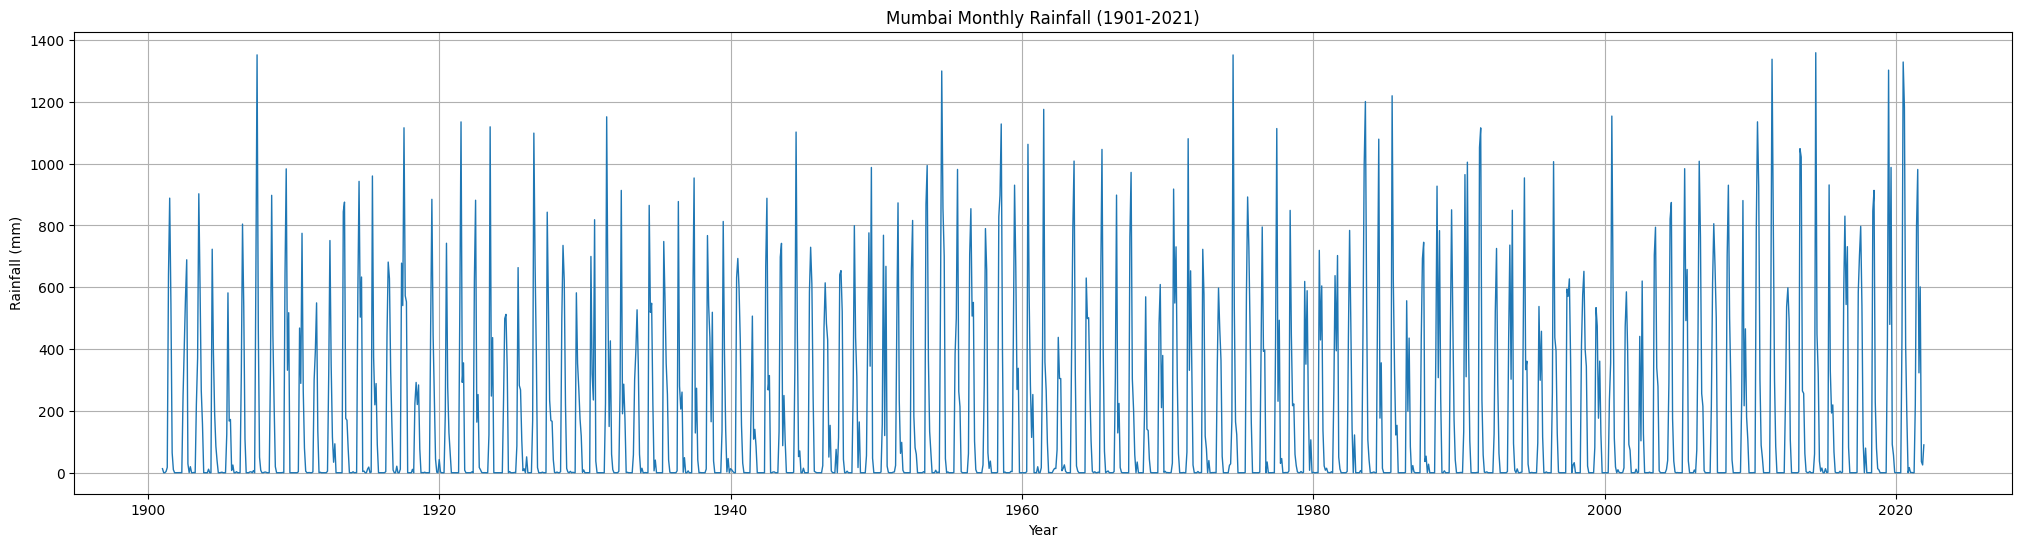

In [16]:
plt.figure(figsize=(25,6))

plt.plot(
    rainfall_ts,
    linewidth=1
)

plt.title("Mumbai Monthly Rainfall (1901-2021)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.grid(True)

plt.show()

# **Step 9: Splitting the Dataset into Training and Testing Sets**

In this step, the rainfall time series was divided into two parts: a **training set** and a **testing set**.

### Why was the Dataset Split?

To evaluate the forecasting models fairly, historical data was used for training, while more recent data was reserved for testing. This allows the model to generate forecasts and compare them with actual observed rainfall values.

### Understanding the Output

- **Training Observations:** 1392
  - Used for building and fitting the forecasting models.
  - Covers the period from **January 1901 to December 2016**.

- **Testing Observations:** 60
  - Used for evaluating forecasting accuracy.
  - Covers the period from **January 2017 to December 2021**.

### Dataset Split Summary

| Dataset | Period | Observations |
|----------|----------|----------|
| Training Set | 1901 - 2016 | 1392 |
| Testing Set | 2017 - 2021 | 60 |


In [17]:
train = rainfall_ts[:'2016-12-01']

test = rainfall_ts['2017-01-01':]

print("Training Observations:", len(train))

print("Testing Observations:", len(test))

print("\nTrain Start:", train.index.min())
print("Train End:", train.index.max())

print("\nTest Start:", test.index.min())
print("Test End:", test.index.max())

Training Observations: 1392
Testing Observations: 60

Train Start: 1901-01-01 00:00:00
Train End: 2016-12-01 00:00:00

Test Start: 2017-01-01 00:00:00
Test End: 2021-12-01 00:00:00


# **5. Simple Exponential Smoothing (SES)**

## **5.1 Training the SES Model**

In this step, the Simple Exponential Smoothing (SES) model was trained using the rainfall data from the training set.

SES is one of the simplest forecasting techniques and is suitable for time series data that contains only a level component without trend or seasonality. The model assigns greater importance to recent observations while gradually reducing the influence of older observations.

After fitting the model on the training dataset, forecasts were generated for the testing period (2017–2021).

### Understanding the Output

The forecasted values are approximately **3.37 mm** for each month.

This occurs because SES assumes that future observations will remain close to the estimated overall level of the historical series. Since the model does not account for trend or seasonal rainfall patterns, it produces nearly constant forecasts throughout the prediction period.


In [18]:
ses_model = SimpleExpSmoothing(
    train
).fit()

ses_forecast = ses_model.forecast(
    len(test)
)

ses_forecast.head()

,0
2017-01-01,3.366276
2017-02-01,3.366276
2017-03-01,3.366276
2017-04-01,3.366276
2017-05-01,3.366276


## **5.2 SES Forecast Visualization**

In this step, the forecasted values generated by the Simple Exponential Smoothing (SES) model were plotted and compared with the actual rainfall observations.

### Understanding the Graph

The graph contains three components:

- **Training Data (Blue)** – Historical rainfall data used to train the SES model.
- **Actual Rainfall (Orange)** – Observed rainfall values from 2017 to 2021.
- **SES Forecast (Green Dashed Line)** – Rainfall values predicted by the SES model.

### Observations

- The actual rainfall series shows large fluctuations throughout the testing period.
- Rainfall increases significantly during monsoon months and decreases during dry months.
- The SES forecast remains almost constant across the entire testing period.
- The model fails to follow the seasonal peaks and troughs visible in the actual rainfall data.


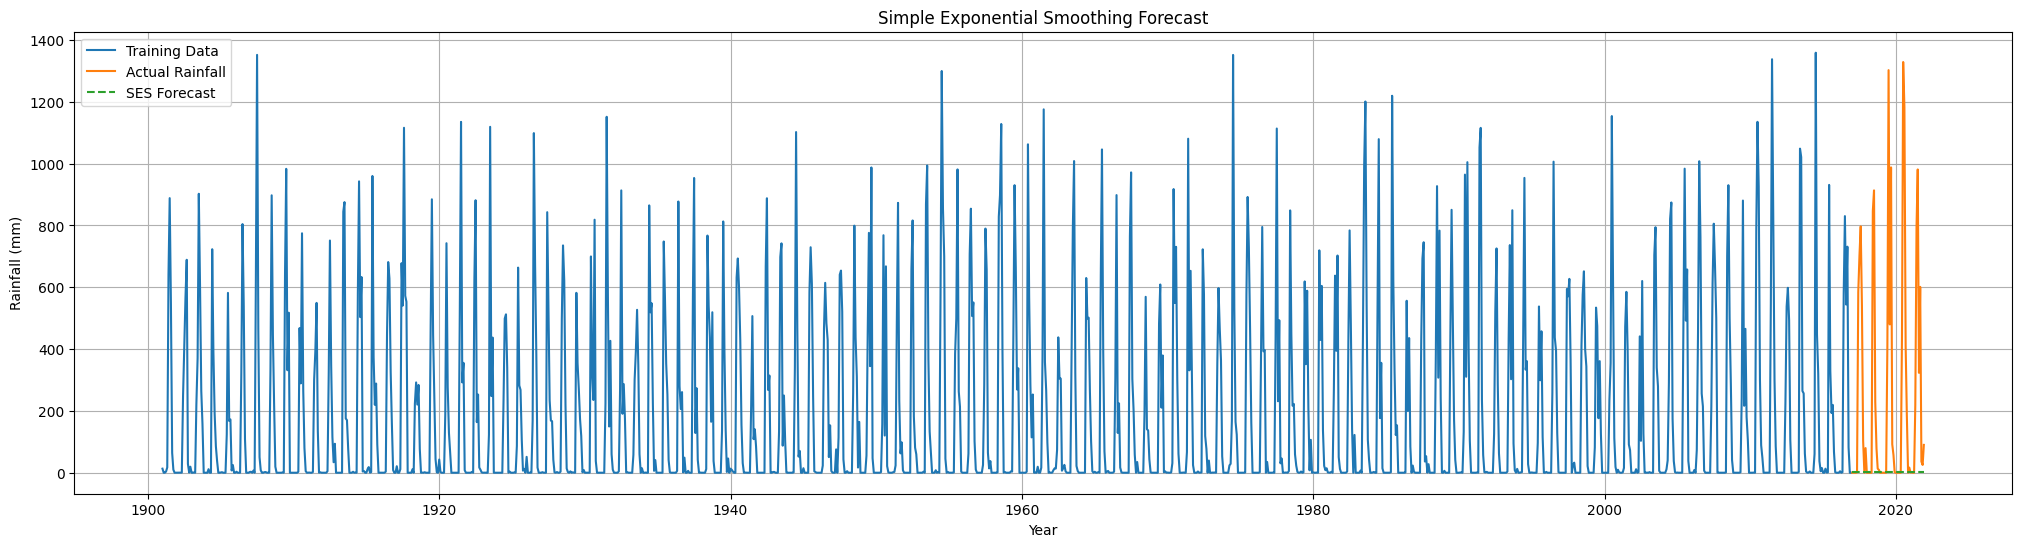

In [20]:
plt.figure(figsize=(25,6))

plt.plot(
    train,
    label='Training Data'
)

plt.plot(
    test,
    label='Actual Rainfall'
)

plt.plot(
    ses_forecast,
    label='SES Forecast',
    linestyle='--'
)

plt.title("Simple Exponential Smoothing Forecast")

plt.xlabel("Year")

plt.ylabel("Rainfall (mm)")

plt.legend()

plt.grid(True)

plt.show()

## **5.3 SES Model Evaluation**

In this step, the performance of the Simple Exponential Smoothing (SES) model was evaluated using two error metrics: Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

### Understanding the Metrics

- **Mean Absolute Error (MAE)**
  - Measures the average absolute difference between actual and forecasted rainfall values.
  - Lower MAE values indicate better forecasting accuracy.

- **Root Mean Squared Error (RMSE)**
  - Measures the magnitude of forecasting errors.
  - Larger errors receive greater penalties.
  - Lower RMSE values indicate a more accurate model.

### Results

| Metric | Value |
|----------|----------|
| MAE | 247.44 |
| RMSE | 448.24 |

The SES model produced a **MAE of 247.44 mm** and an **RMSE of 448.24 mm**.

These relatively high error values indicate that the model was unable to accurately capture the rainfall pattern of Mumbai. Since SES only considers the overall level of the series and ignores seasonality, it fails to model the strong monsoon-driven rainfall fluctuations present in the dataset.


In [21]:
ses_mae = mean_absolute_error(
    test,
    ses_forecast
)

ses_rmse = np.sqrt(
    mean_squared_error(
        test,
        ses_forecast
    )
)

print("SES MAE :", round(ses_mae,2))

print("SES RMSE:", round(ses_rmse,2))

SES MAE : 247.44
SES RMSE: 448.24


# **6. Holt's Linear Trend Method**

## **6.1 Training the Holt Model**

In this step, Holt’s Linear Trend Method was applied to the training dataset to generate rainfall forecasts for the testing period.

Unlike Simple Exponential Smoothing (SES), Holt’s method considers both the level and trend components of a time series. This allows the model to capture long-term increasing or decreasing patterns in the data.

### Understanding the Output

The first few forecasted values generated by the model are negative and continue to decrease over time.

| Date | Forecasted Rainfall (mm) |
|----------|----------:|
| 2017-01 | -1.60 |
| 2017-02 | -5.78 |
| 2017-03 | -9.96 |
| 2017-04 | -14.14 |

The forecast values indicate a continuous downward trend in rainfall. Since Mumbai rainfall exhibits strong seasonal behaviour rather than a simple linear trend, Holt’s method is unable to represent the data accurately.

The negative rainfall forecasts further suggest that a trend-only model is not suitable for forecasting Mumbai rainfall.

In [22]:
holt_model = Holt(
    train
).fit()

holt_forecast = holt_model.forecast(
    len(test)
)

holt_forecast.head()

,0
2017-01-01,-1.601469
2017-02-01,-5.781919
2017-03-01,-9.962369
2017-04-01,-14.142818
2017-05-01,-18.323268


## **6.2 Holt Forecast Visualization**

In this step, the forecasts generated by Holt’s Linear Trend Method were visualized and compared with the actual rainfall observations.

### Understanding the Graph

The graph contains three components:

- **Training Data (Blue)** – Historical rainfall data used to train the model.
- **Actual Rainfall (Orange)** – Observed rainfall values during the testing period (2017–2021).
- **Holt Forecast (Green Dashed Line)** – Forecasted rainfall values generated by Holt’s method.

### Observations

- The actual rainfall series exhibits strong seasonal fluctuations throughout the testing period.
- High rainfall peaks can be observed during the monsoon months, while very low rainfall is recorded during dry months.
- The Holt forecast follows a continuously decreasing trend.
- Forecasted values eventually become negative, which is not realistic for rainfall data.
- The forecast does not capture the recurring seasonal pattern visible in the actual observations.


The visualization clearly shows that Holt’s Linear Trend Method is unable to model the seasonal behaviour of the Mumbai rainfall dataset. Since the model only considers level and trend components, it ignores the strong annual monsoon cycle.

As a result, the forecast diverges significantly from the actual rainfall observations, leading to unrealistic negative predictions and poor forecasting performance.

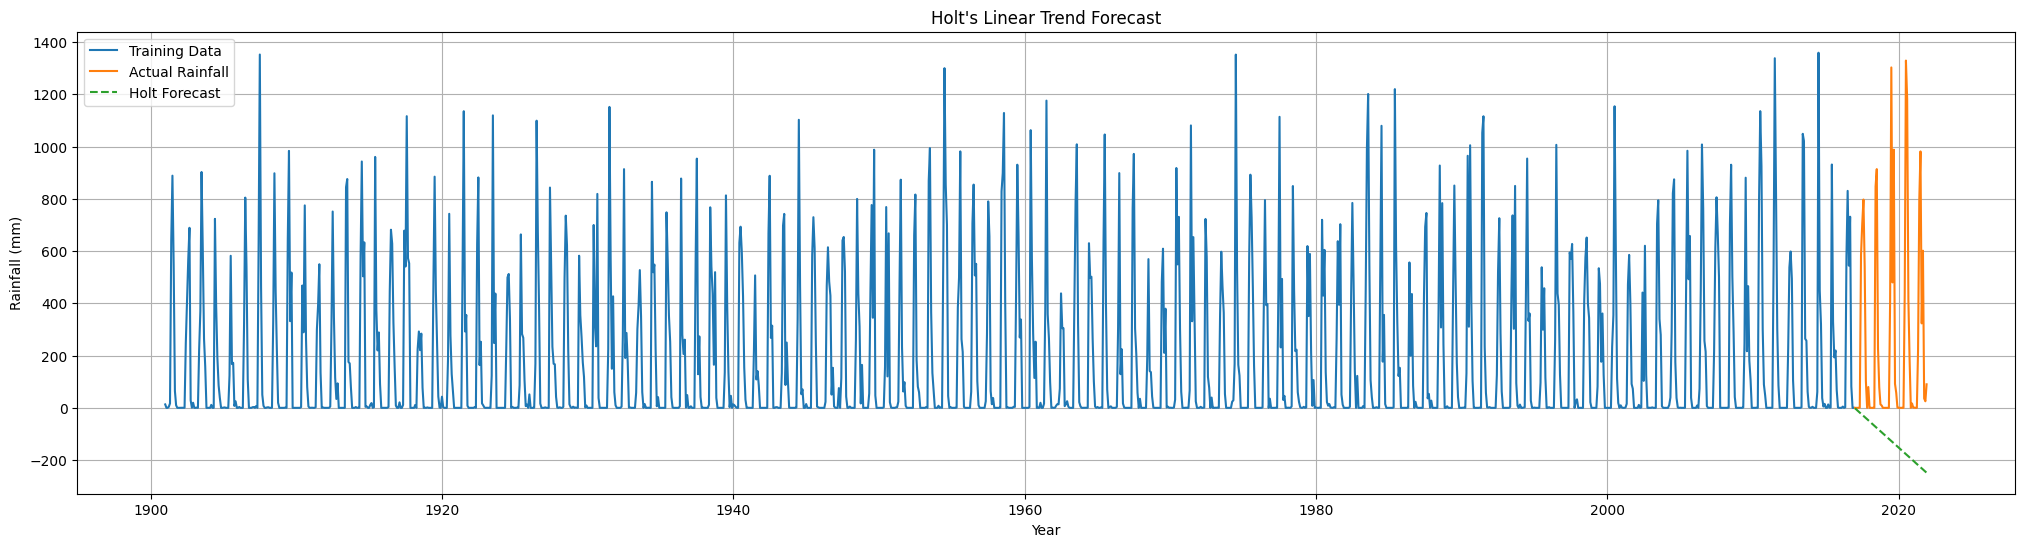

In [24]:
plt.figure(figsize=(25,6))

plt.plot(
    train,
    label='Training Data'
)

plt.plot(
    test,
    label='Actual Rainfall'
)

plt.plot(
    holt_forecast,
    label='Holt Forecast',
    linestyle='--'
)

plt.title("Holt's Linear Trend Forecast")

plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.legend()

plt.grid(True)

plt.show()

# **6.3 Holt Model Evaluation**
The performance of the Holt’s Linear Trend Method was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) on the test dataset spanning from January 2017 to December 2021. These metrics provide a quantitative measure of the forecasting accuracy by comparing the predicted rainfall values with the actual observations.

#### Understanding the Output

The evaluation results obtained for the Holt model are:

- **MAE = 372.71**
- **RMSE = 539.20**

These values indicate the average forecasting error and the overall deviation between the actual and forecasted rainfall values.

#### Observations

- The Holt model produced relatively high error values on the test dataset.
- The RMSE value is considerably higher than the MAE value, indicating the presence of some large forecasting errors.
- Although the model captures the overall trend in the data, it does not account for seasonal rainfall fluctuations.



The results suggest that Holt’s Linear Trend Method is not well suited for forecasting Mumbai rainfall data. Since rainfall patterns exhibit strong seasonality due to monsoon effects, a model that considers only trend components cannot accurately represent the underlying data behavior. Therefore, seasonal exponential smoothing techniques such as the Holt-Winters methods are expected to provide improved forecasting performance.

In [25]:
holt_mae = mean_absolute_error(
    test,
    holt_forecast
)

holt_rmse = np.sqrt(
    mean_squared_error(
        test,
        holt_forecast
    )
)

print("Holt MAE :", round(holt_mae,2))

print("Holt RMSE:", round(holt_rmse,2))

Holt MAE : 372.71
Holt RMSE: 539.2


# **7. Holt-Winters Additive Method**

The Holt-Winters Additive Method is an extension of Holt’s Linear Trend Method that incorporates both trend and seasonal components. This method is suitable when seasonal variations remain relatively constant over time. Since monthly rainfall data exhibits recurring seasonal patterns, the additive model can effectively capture both long-term trends and seasonal fluctuations.

## 7.1 Training the HW Additive Model

The Holt-Winters Additive model was trained using the training dataset from January 1901 to December 2016. The model was configured with an additive trend component and an additive seasonal component, with a seasonal period of 12 months to represent yearly rainfall seasonality.

### Understanding the Output

The model was fitted to the historical rainfall data and forecasts were generated for the test period. The displayed output shows the first few forecasted rainfall values beginning from January 2017.

### Observations

- Forecast values were successfully generated for the test dataset.
- The model captures both trend and seasonal components present in the rainfall series.
- Predicted values vary across months, indicating that seasonal patterns have been incorporated into the forecasting process.

The successful generation of forecasts indicates that the Holt-Winters Additive model has learned the underlying trend and seasonal structure of the rainfall data. By considering both components simultaneously, the model is expected to provide more accurate forecasts than methods that account only for level or trend.

In [26]:
hw_add_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

hw_add_forecast = hw_add_model.forecast(
    len(test)
)

hw_add_forecast.head()

,0
2017-01-01,14.436615
2017-02-01,14.452971
2017-03-01,15.212962
2017-04-01,15.125203
2017-05-01,34.784937


# **7.2 HW Additive Forecast Visualization**

The forecast generated by the Holt-Winters Additive model was visualized alongside the training data and actual rainfall observations from the test period. This comparison helps assess how effectively the model captures the underlying trend and seasonal patterns present in the rainfall time series.

### Understanding the Graph

The graph contains three components:

- **Training Data (Blue Line):** Historical monthly rainfall observations used to train the model.
- **Actual Rainfall (Orange Line):** Observed rainfall values during the test period (2017–2021).
- **HW Additive Forecast (Green Dashed Line):** Forecasted rainfall values produced by the Holt-Winters Additive model.

The forecast line follows a recurring seasonal pattern, reflecting the annual rainfall cycle learned from the historical data.

### Observations

- The forecasted values exhibit clear seasonal fluctuations throughout the test period.
- The model successfully captures the periodic rainfall behavior observed in the historical dataset.
- Forecast peaks and troughs generally align with the seasonal pattern of the actual rainfall data.
- Some differences between actual and forecasted rainfall values are visible, particularly during months with extreme rainfall events.

The Holt-Winters Additive model effectively incorporates both trend and seasonality into the forecasting process. The visualization indicates that the model is capable of reproducing the overall seasonal structure of Mumbai rainfall data. However, variations between the forecasted and actual values suggest that the model may not fully capture unusually high or low rainfall events, which are common in weather-related time series.

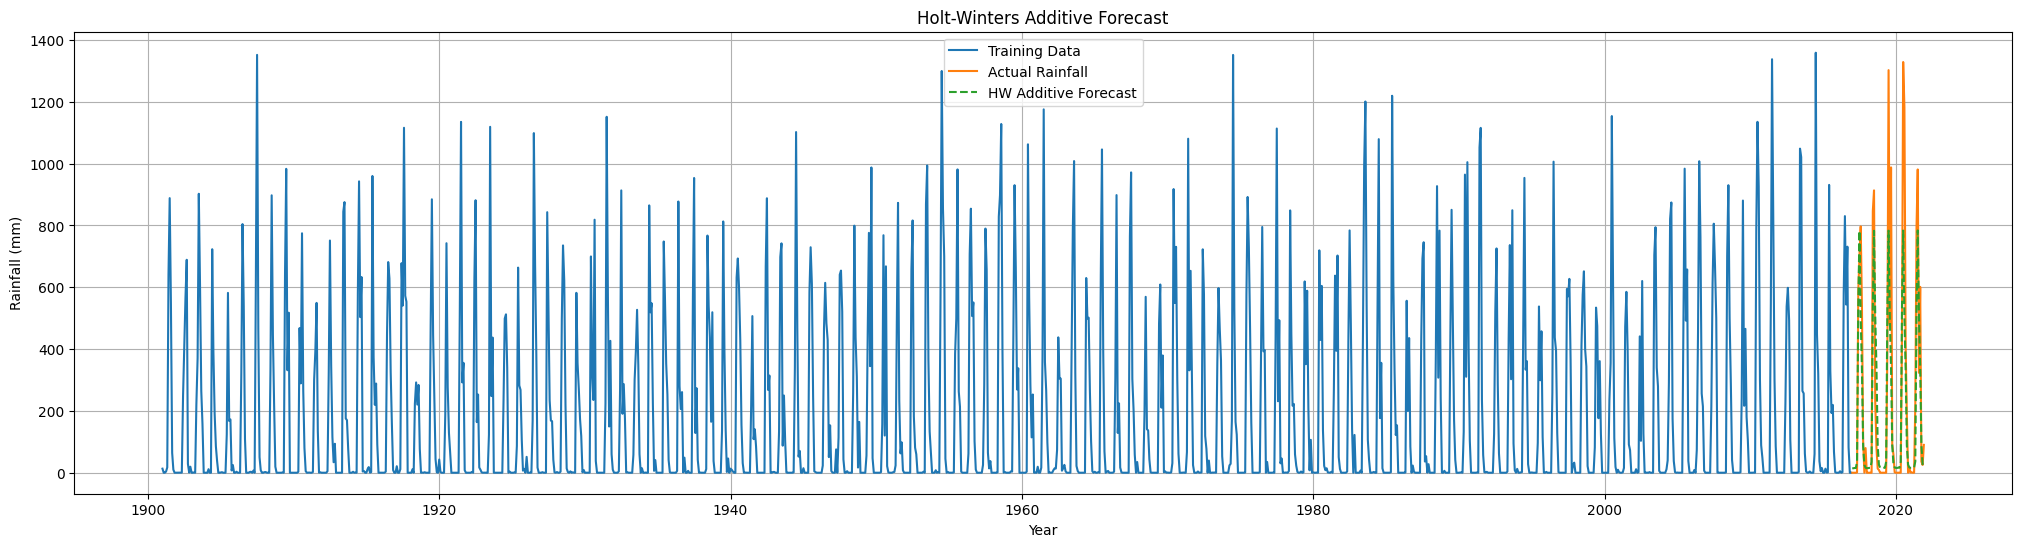

In [28]:
plt.figure(figsize=(25,6))

plt.plot(
    train,
    label='Training Data'
)

plt.plot(
    test,
    label='Actual Rainfall'
)

plt.plot(
    hw_add_forecast,
    label='HW Additive Forecast',
    linestyle='--'
)

plt.title("Holt-Winters Additive Forecast")

plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.legend()

plt.grid(True)

plt.show()

# **7.3 HW Additive Model Evaluation**

The performance of the Holt-Winters Additive model was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) on the test dataset covering the period from January 2017 to December 2021. These metrics were used to assess the forecasting accuracy of the model by comparing the predicted rainfall values with the actual observations.

### Understanding the Output

The evaluation results obtained for the Holt-Winters Additive model are:

- **MAE = 106.01**
- **RMSE = 189.67**

These values indicate that the model achieved substantially lower forecasting errors compared to both the SES and Holt models.

### Observations

- The Holt-Winters Additive model produced a significant reduction in both MAE and RMSE.
- The forecasted values closely follow the seasonal pattern present in the rainfall data.
- The lower error values demonstrate the importance of incorporating seasonality into the forecasting process.
- The model performs considerably better than methods that only account for level or trend components.

The results indicate that the Holt-Winters Additive model provides accurate forecasts for Mumbai rainfall data. By incorporating level, trend, and seasonal components, the model is able to capture the recurring rainfall patterns more effectively than SES and Holt’s Linear Trend Method. The relatively low MAE and RMSE values suggest that the additive seasonal approach is well suited for this time series dataset.

In [29]:
hw_add_mae = mean_absolute_error(
    test,
    hw_add_forecast
)

hw_add_rmse = np.sqrt(
    mean_squared_error(
        test,
        hw_add_forecast
    )
)

print("HW Additive MAE :", round(hw_add_mae,2))

print("HW Additive RMSE:", round(hw_add_rmse,2))

HW Additive MAE : 106.01
HW Additive RMSE: 189.67


# **8. Holt-Winters Multiplicative Method**

## **8.1 Training the HW Multiplicative Model**

The Holt-Winters Multiplicative model was trained on the rainfall data from January 1901 to December 2016. Since multiplicative models cannot handle zero values, zero rainfall observations were replaced with a small positive value (0.001) before training. A seasonal period of 12 months was used to capture yearly rainfall seasonality.

### Understanding the Output

The model was successfully fitted and forecasts were generated for the test period starting from January 2017. The output displays the first few forecasted rainfall values.

### Observations

- Forecasts were successfully generated for the test dataset.
- The model captures both trend and seasonal variations.
- Seasonal effects vary according to the rainfall level.

The Holt-Winters Multiplicative model effectively learns the trend and seasonal structure of the rainfall data, making it suitable for forecasting datasets with varying seasonal intensity.

In [32]:
train_mul = train.copy()

train_mul = train_mul.replace(
    0,
    0.001
)

hw_mul_model = ExponentialSmoothing(
    train_mul,
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()

hw_mul_forecast = hw_mul_model.forecast(
    len(test)
)

hw_mul_forecast.head()

,0
2017-01-01,0.545516
2017-02-01,0.423076
2017-03-01,1.990313
2017-04-01,0.895446
2017-05-01,24.612530


# **8.2 HW Multiplicative Forecast Visualization**

The forecast generated by the Holt-Winters Multiplicative model was visualized along with the training data and actual rainfall observations for the test period. This helps evaluate how well the model captures seasonal rainfall patterns.

### Understanding the Graph

The graph shows the historical training data, actual rainfall values from the test period, and the forecasted values generated by the Holt-Winters Multiplicative model.

### Observations

- The forecast follows the seasonal pattern of the rainfall data.
- Forecasted values closely align with the overall trend of the actual rainfall observations.
- Seasonal peaks and variations are effectively represented in the forecast.


The Holt-Winters Multiplicative model successfully captures both trend and varying seasonal effects in the rainfall series. The visualization indicates that the model provides forecasts that closely follow the observed rainfall pattern.

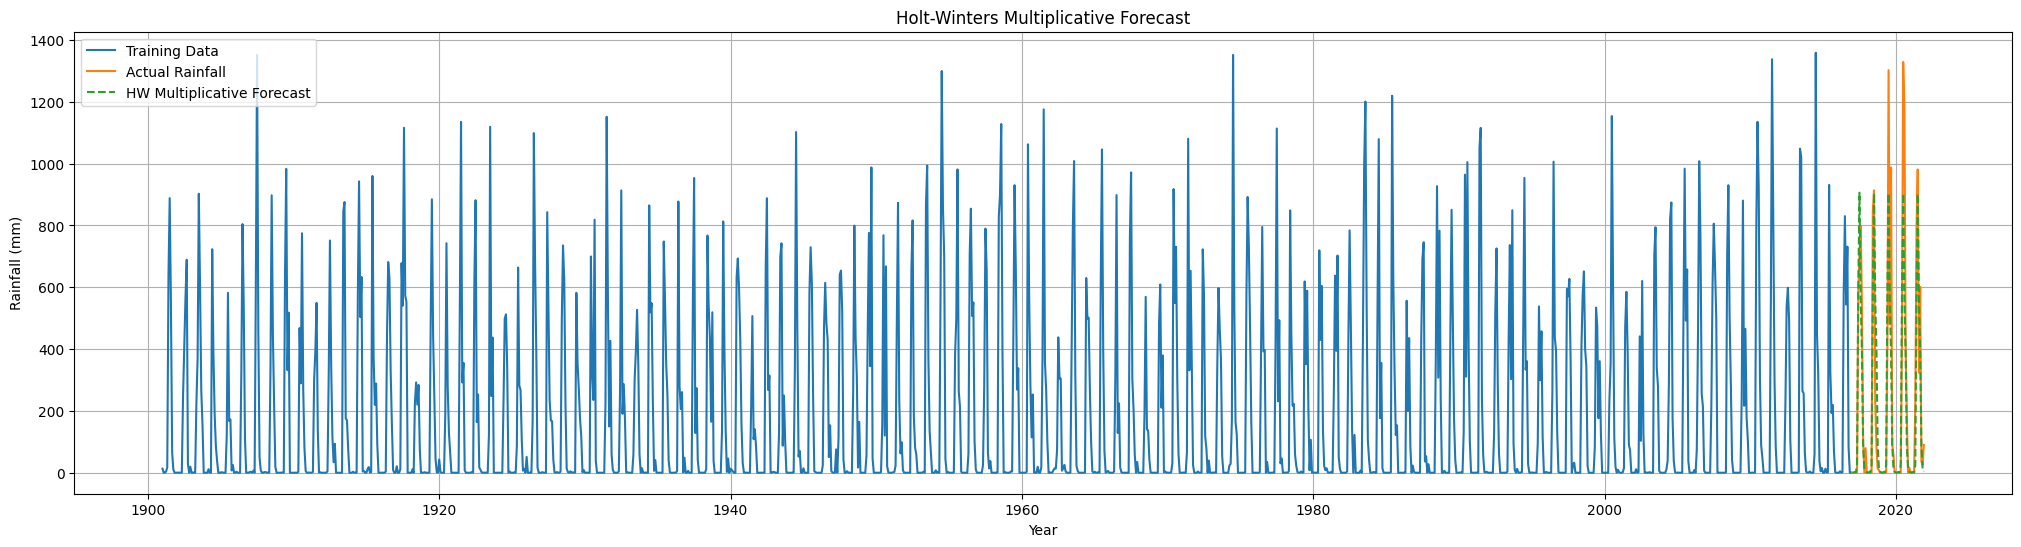

In [33]:
plt.figure(figsize=(25,6))

plt.plot(
    train,
    label='Training Data'
)

plt.plot(
    test,
    label='Actual Rainfall'
)

plt.plot(
    hw_mul_forecast,
    label='HW Multiplicative Forecast',
    linestyle='--'
)

plt.title("Holt-Winters Multiplicative Forecast")

plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.legend()

plt.grid(True)

plt.show()

# **8.3 HW Multiplicative Model Evaluation**

The performance of the Holt-Winters Multiplicative model was evaluated on the test dataset using MAE and RMSE. These metrics were used to measure the difference between the actual and forecasted rainfall values.

### Understanding the Output

The evaluation results obtained for the Holt-Winters Multiplicative model are:

- **MAE = 92.13**
- **RMSE = 171.52**

These are the lowest error values among all the exponential smoothing models considered in this study.

### Observations

- The model achieved the lowest MAE and RMSE values.
- Forecasts closely match the actual rainfall patterns.
- The multiplicative seasonal component effectively captures variations in seasonal intensity.


The Holt-Winters Multiplicative model provides the most accurate forecasts for Mumbai rainfall data. Its ability to model changing seasonal effects results in superior forecasting performance, making it the best-performing model among all the methods evaluated.

In [34]:
hw_mul_mae = mean_absolute_error(
    test,
    hw_mul_forecast
)

hw_mul_rmse = np.sqrt(
    mean_squared_error(
        test,
        hw_mul_forecast
    )
)

print("HW Multiplicative MAE :", round(hw_mul_mae,2))

print("HW Multiplicative RMSE:", round(hw_mul_rmse,2))

HW Multiplicative MAE : 92.13
HW Multiplicative RMSE: 171.52


# **9. Future Rainfall Forecast (2022–2026)**

## **9.1 Monthly Rainfall Forecast**

The Holt-Winters Multiplicative model was selected as the best-performing model based on its lowest MAE and RMSE values. Using this model, monthly rainfall forecasts were generated for the period 2022 to 2026.

### Understanding the Output

The output displays the forecasted monthly rainfall values for the next five years. The forecasts show a clear seasonal pattern, with higher rainfall during the monsoon months and lower rainfall during the remaining months of the year.

### Observations

- Forecasts were generated for 60 future months (2022–2026).
- Highest rainfall values are observed during the monsoon season.
- Rainfall remains low during non-monsoon months.
- The seasonal rainfall pattern remains consistent across the forecast period.

The forecast suggests that Mumbai is expected to continue experiencing a strong seasonal rainfall pattern over the next five years. The results indicate stable monsoon behavior with no significant changes in the overall rainfall trend.

In [38]:
full_data = rainfall_ts.replace(0, 0.001)

best_model = ExponentialSmoothing(
    full_data,
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()

future_forecast = best_model.forecast(60)

future_df = pd.DataFrame({
    "Forecasted Rainfall (mm)": future_forecast
})

future_df

,Forecasted Rainfall (mm)
2022-01-01,0.508376
2022-02-01,0.413459
2022-03-01,1.633103
2022-04-01,0.711455
2022-05-01,37.455567
2022-06-01,692.684090
2022-07-01,1108.086980
2022-08-01,671.083048
2022-09-01,503.210737
2022-10-01,101.090340


# **9.2 Annual Rainfall Forecast**

The forecasted monthly rainfall values were aggregated to obtain annual rainfall estimates for the period 2022–2026. This provides an overview of the expected yearly rainfall trend in Mumbai.

### Understanding the Output

The table presents the forecasted annual rainfall totals from 2022 to 2026 based on the Holt-Winters Multiplicative model.

| Year | Forecasted Annual Rainfall (mm) |
|------|--------------------------------|
| 2022 | 3143.04 |
| 2023 | 3159.50 |
| 2024 | 3175.96 |
| 2025 | 3192.42 |
| 2026 | 3208.87 |

### Observations

- Annual rainfall shows a gradual increase over the forecast period.
- All forecasted yearly totals exceed 3100 mm.
- The increase in rainfall remains consistent from year to year.

The forecast indicates a slight upward trend in Mumbai's annual rainfall from 2022 to 2026. The results suggest that the city is likely to continue experiencing strong monsoon rainfall with relatively stable seasonal patterns.

In [39]:
yearly_forecast = future_df.resample('YE').sum()

yearly_forecast.index = yearly_forecast.index.year

yearly_forecast.columns = ['Annual Rainfall Forecast (mm)']

yearly_forecast

,Annual Rainfall Forecast (mm)
2022,3143.040627
2023,3159.498991
2024,3175.957355
2025,3192.415719
2026,3208.874084


# **10. Model Comparison**

## **10.1 Comparison of MAE and RMSE**

The forecasting performance of the four Exponential Smoothing models was compared using MAE and RMSE values. Lower values indicate better forecasting accuracy.

| Model | MAE | RMSE |
|---------|---------|---------|
| SES | 247.44 | 448.24 |
| Holt | 372.71 | 539.20 |
| HW Additive | 106.01 | 189.67 |
| HW Multiplicative | 92.13 | 171.52 |

### Understanding the Output

The comparison table shows the forecasting errors produced by each model on the test dataset. The model with the lowest MAE and RMSE is considered the most accurate.

### Observations

#### **Simple Exponential Smoothing (SES)**

- MAE = 247.44
- RMSE = 448.24

SES considers only the level component and ignores both trend and seasonality. Since Mumbai rainfall data exhibits strong seasonal variations due to the monsoon cycle, the model is unable to capture recurring rainfall patterns effectively, resulting in relatively high forecasting errors.

#### **Holt's Linear Trend Method**

- MAE = 372.71
- RMSE = 539.20

Holt's method incorporates level and trend components but does not account for seasonality. The rainfall dataset is dominated by seasonal fluctuations rather than a strong long-term trend. Consequently, the model fails to represent the annual monsoon cycle accurately and produces the highest forecasting errors.

#### **Holt-Winters Additive Method**

- MAE = 106.01
- RMSE = 189.67

The additive Holt-Winters model incorporates level, trend, and seasonal components. It successfully captures the recurring seasonal rainfall pattern and significantly reduces forecasting errors compared to SES and Holt models.

#### **Holt-Winters Multiplicative Method**

- MAE = 92.13
- RMSE = 171.52

The multiplicative Holt-Winters model captures level, trend, and varying seasonal effects. Since Mumbai rainfall shows large differences between monsoon and non-monsoon months, the multiplicative seasonal component models these variations more effectively, resulting in the lowest forecasting errors.

The comparison clearly indicates that seasonality is the most important characteristic of the Mumbai rainfall dataset. Models that ignore seasonal behavior (SES and Holt) perform poorly, whereas Holt-Winters models achieve substantially better accuracy. Among all models, the Holt-Winters Multiplicative method provides the best forecasting performance and is therefore selected as the final forecasting model.

In [40]:
comparison = pd.DataFrame({
    "Model": [
        "SES",
        "Holt",
        "HW Additive",
        "HW Multiplicative"
    ],
    "MAE": [
        ses_mae,
        holt_mae,
        hw_add_mae,
        hw_mul_mae
    ],
    "RMSE": [
        ses_rmse,
        holt_rmse,
        hw_add_rmse,
        hw_mul_rmse
    ]
})

comparison

,Model,MAE,RMSE
0,SES,247.435161,448.236958
1,Holt,372.713867,539.203109
2,HW Additive,106.009076,189.665969
3,HW Multiplicative,92.133261,171.516720


# **10. Model Comparison**

## **10.2 Comparison Graph**

A bar graph was plotted to visually compare the MAE and RMSE values of all four Exponential Smoothing models. This graphical representation helps identify the model with the best forecasting performance.

### Understanding the Graph

The graph displays the MAE and RMSE values for the following models:

- Simple Exponential Smoothing (SES)
- Holt's Linear Trend Method
- Holt-Winters Additive Method
- Holt-Winters Multiplicative Method

Lower bar heights indicate lower forecasting errors and better model performance.

### Observations

- Holt's Linear Trend Method has the highest MAE and RMSE values, indicating the poorest forecasting performance.
- SES performs better than Holt but still produces relatively high errors.
- Both Holt-Winters models show significantly lower error values than SES and Holt.
- Holt-Winters Multiplicative has the lowest MAE and RMSE values among all models.
- The error difference between the Holt-Winters models and the other models is clearly visible in the graph.


The graph confirms that incorporating seasonality substantially improves forecasting accuracy for Mumbai rainfall data. Since rainfall follows a strong annual monsoon cycle, models that account for seasonal variations perform considerably better. The Holt-Winters Multiplicative model achieves the lowest forecasting errors and is therefore selected as the most suitable model for future rainfall forecasting.

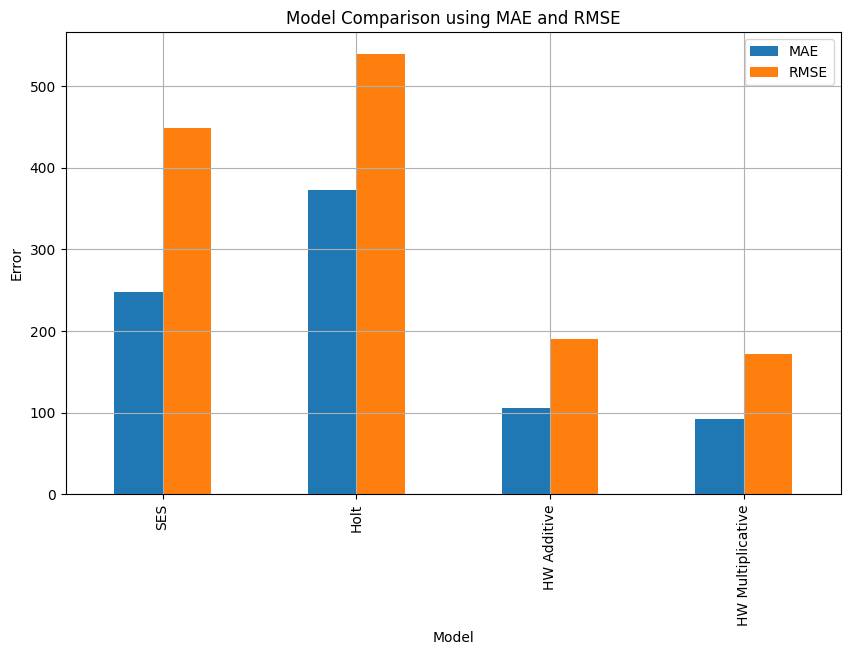

In [41]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison using MAE and RMSE")
plt.ylabel("Error")
plt.xlabel("Model")
plt.grid(True)z

plt.show()

# **10. Model Comparison**

## **10.3 Forecast Comparison Graph**

A comparison graph was plotted to visualize the forecasts generated by all four Exponential Smoothing models against the actual rainfall observations during the test period (2017–2021).

### Understanding the Graph

The graph compares the actual rainfall values with the forecasts produced by SES, Holt, Holt-Winters Additive, and Holt-Winters Multiplicative models.

### Observations

- The SES forecast remains nearly constant and fails to capture the seasonal rainfall pattern.
- The Holt forecast follows a downward trend and even produces negative rainfall values, indicating poor suitability for this dataset.
- The Holt-Winters Additive forecast successfully captures the seasonal pattern but slightly underestimates some monsoon peaks.
- The Holt-Winters Multiplicative forecast follows the actual rainfall pattern more closely than the other models.
- Peak rainfall periods during the monsoon season are represented most accurately by the Holt-Winters Multiplicative model.

The graph clearly shows that Mumbai rainfall is dominated by strong seasonality rather than a simple trend. Models that do not account for seasonal effects, such as SES and Holt, fail to accurately represent the rainfall pattern. The Holt-Winters models perform significantly better because they incorporate seasonal components. Among them, the Holt-Winters Multiplicative model provides the closest match to the actual rainfall observations, confirming its superiority for forecasting Mumbai rainfall.

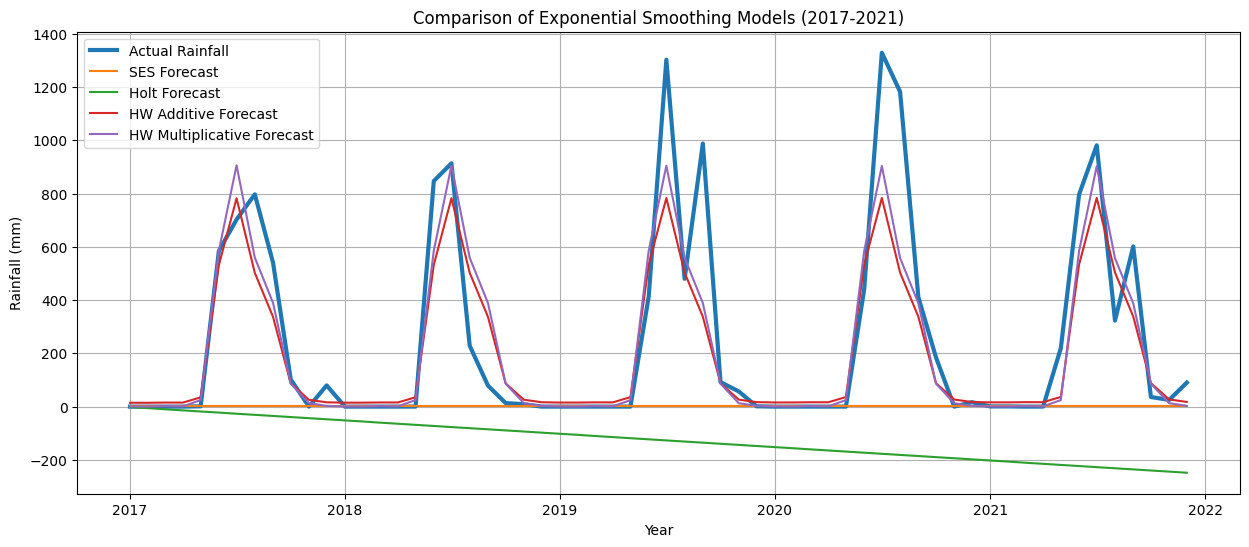

In [46]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test,
    label='Actual Rainfall',
    linewidth=3
)

plt.plot(
    ses_forecast.index,
    ses_forecast,
    label='SES Forecast'
)

plt.plot(
    holt_forecast.index,
    holt_forecast,
    label='Holt Forecast'
)

plt.plot(
    hw_add_forecast.index,
    hw_add_forecast,
    label='HW Additive Forecast'
)

plt.plot(
    hw_mul_forecast.index,
    hw_mul_forecast,
    label='HW Multiplicative Forecast'
)

plt.title("Comparison of Exponential Smoothing Models (2017-2021)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.legend()
plt.grid(True)

plt.show()

# **10.4 Final Ranking of Models**

Based on the MAE, RMSE, and visual forecast comparison results, the forecasting models are ranked as follows:

| Rank | Model | MAE | RMSE |
|------|--------|--------|--------|
| 1 | Holt-Winters Multiplicative | 92.13 | 171.52 |
| 2 | Holt-Winters Additive | 106.01 | 189.67 |
| 3 | Simple Exponential Smoothing (SES) | 247.44 | 448.24 |
| 4 | Holt's Linear Trend Method | 372.71 | 539.20 |

### Key Findings

#### **1. Seasonality is the Most Important Component**

Mumbai rainfall data exhibits a strong yearly monsoon cycle. Rainfall remains very low during most months and increases sharply during June–September. Therefore, models that incorporate seasonality perform significantly better than those that do not.

#### **2. Trend Alone is Not Sufficient**

The seasonal component is much more dominant than the long-term trend component in the rainfall series. The large difference between monsoon and non-monsoon rainfall indicates strong seasonal variation. As a result, Holt's Linear Trend Method, which focuses mainly on trend, produced the highest forecasting errors.

#### **3. SES Cannot Capture Monsoon Patterns**

Simple Exponential Smoothing considers only the level component and ignores both trend and seasonality. Consequently, it fails to model the sharp seasonal rainfall variations observed in the dataset.

#### **4. Holt-Winters Models Perform Better**

Both Holt-Winters models incorporate seasonal effects and successfully capture the recurring monsoon pattern. This leads to a substantial reduction in forecasting errors compared to SES and Holt.

#### **5. Multiplicative Seasonality Best Fits the Dataset**

The large difference between monsoon and non-monsoon rainfall indicates that seasonal effects vary with the level of rainfall. The Holt-Winters Multiplicative model captures these varying seasonal fluctuations more effectively than the Additive model, resulting in the lowest MAE and RMSE values.

### Final Observation

The Holt-Winters Multiplicative model achieved the lowest MAE (92.13) and RMSE (171.52) values among all evaluated models. Therefore, it was selected as the final forecasting model for predicting future rainfall in Mumbai.
The analysis demonstrates that Mumbai rainfall forecasting is primarily driven by seasonal behavior rather than trend. Therefore, the Holt-Winters Multiplicative model is the most suitable forecasting technique for this dataset and was selected for future rainfall prediction.